In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, quad
import src.ratelaws as rate

# Cinética de Procesos (Sesión 03)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño


2025

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

**Consideraciones generales:**

- Muchas veces, los procesos constan de varios reactores conectados en serie de tal forma que la salida de un reactor alimenta al siguiente reactor en la cadena.

- La dependencia entre $r_{\mathrm{A}}$ y $X$ puede expresarse de varias formas:
    - Empírica a partir de experimentos.
    - Mediante una función que relacione una ley de velocidad de reacción y la conversión.

# 5. Reacciones Autocatalíticas

## 5.1 Definiciones

**Consideraciones generales:**

Una reacción autocatalítica es aquella en que la ley de reacción involucra tanto reactivos como productos.

$$\mathrm{A + R \rightarrow R + R}$$

$$ -r_{\mathrm{A}} = k C_{\mathrm{A}}^{\alpha} C_{\mathrm{R}}^{r}$$

Características :

- Al inicio la tasa de reacción puede ser lenta, si existe poco producto presente.

- En algún momento se alcanza una tasa de reacción máxima.

- Cerca del final de la reacción, la tasa de reacción disminuye, debido al agotamiento del reactivo limitante.

In [32]:
# Reacción (aA --> rR)
species = [r"A", r"R"]
k = 1.0
cA0 = 0.5
cR0 = 0
oA = 0.5
oR = 0.5

X = np.linspace(1e-2, 0.99, 100)
# cálculo de tabla estequiométrica
s = np.array([-1, 1])
n0 = np.array([cA0, cR0])
tr = n0/n0[0]
sr = s/s[0]
n = np.empty(shape=(len(species), len(X)))
for i in range(len(n)):
    n[i] = n0[0] * (tr[i] - sr[i]*X)
rA = -1.0*rate.rateRP(k, n[0], n[1], oA, oR)
# Creación de DataFrame con datos de interés
df = pd.DataFrame({"X": X, '-rA': -rA})
df['1/-rA'] = 1/df['-rA'] # [(mol-1.m3).s]
display(df)

,X,-rA,1/-rA
0,0.010000,0.049749,20.100756
1,0.019899,0.069827,14.321189
2,0.029798,0.085015,11.762659
3,0.039697,0.097623,10.243472
4,0.049596,0.108554,9.211974
...,...,...,...
95,0.950404,0.108554,9.211974
96,0.960303,0.097623,10.243472
97,0.970202,0.085015,11.762659
98,0.980101,0.069827,14.321189


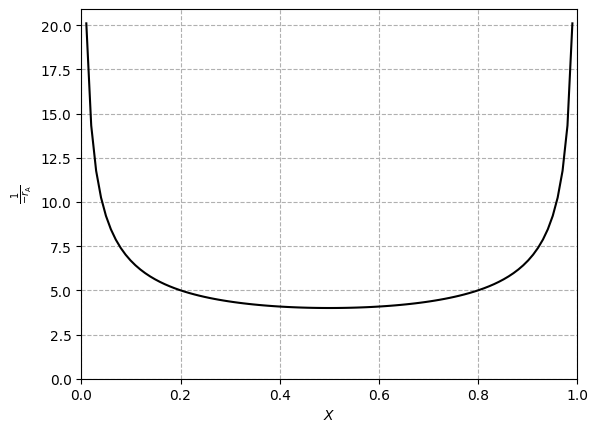

In [33]:
x, y = df['X'].to_numpy(), 1/df['-rA'].to_numpy()

fig, ax = plt.subplots()
ax.plot(x, y, c='k')
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$\frac{1}{-r_{\mathrm{A}}}$")
ax.set_xlim(0, 1)
ax.set_ylim(0,)
ax.grid(ls='--')
plt.show()

## 5.2 Reactores CSTR / PFR

In [39]:
target = 0.5 # target conversion
F0 = 5 # flujo molar

### 5.2.1 CSTR vs PFR (sin recirculación)

Utilizando un gráfico $1/-r{\mathrm{A}}$ vs $X$, se puede observar cuál reactor tendrá un mejor desempeño (menor área):

- A conversiones bajas, el reactor CSTR tiene mejor desempeño que un PFR.
- A conversiones altas, el reactor PFR tiene mejor desempeño que un CSTR.

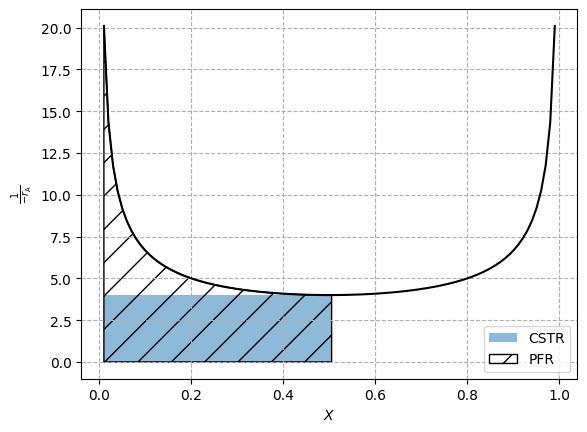

    n    Volumen    Tipo
-----------------------
   1   |   9.8995 | CSTR
   1   |  13.8423 | PFR


In [40]:
# gráfico
fig, ax = plt.subplots()
ax.plot(x, y, color='k')
# Encontrar índices cercanos a la conversión final
x1 = target
diffs1 = np.abs(x1 - x)
ind1 = diffs1.argmin()
### CSTR
areaCSTR = (x[ind1] - x[0]) * y[ind1]
ax.fill_between(x[:ind1+1], y[ind1]*np.ones_like(x[:ind1+1]), alpha=0.5, label="CSTR")
### PFR
areaPFR = trapezoid(y[:ind1+1], x[:ind1+1])
ax.fill_between(x[:ind1+1], y[:ind1+1], hatch='/', facecolor='None', edgecolor='k', label='PFR')
# formato gráfico
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$\frac{1}{-r_{\mathrm{A}}}$")
ax.legend()
ax.grid(ls='--')
plt.show()

### Tratamiento de datos #######################################################
# Establecer flujo molar (regimen estacionario), calcular volumenes de reactores
# imprimir resultados brutos
print("    n    Volumen    Tipo")
print("-----------------------")
print(f"   1   | {F0*areaCSTR:8.4f} | {'CSTR'}")
print(f"   1   | {F0*areaPFR:8.4f} | {'PFR'}")

**¿A que nivel de conversión las áreas son similares?**

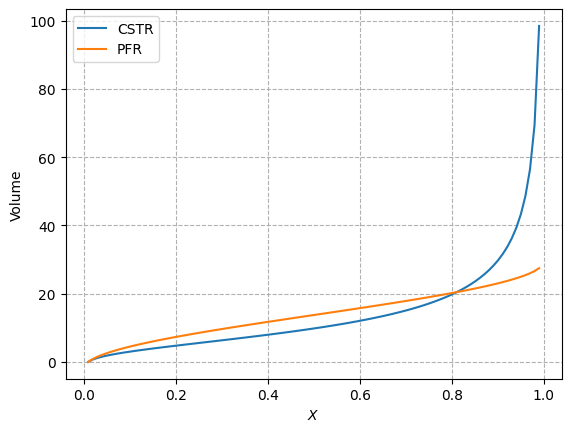

In [41]:
# volumen CSTR o PFR en funcion de la conversion
fig, ax = plt.subplots()
areasCSTR, areasPFR = np.zeros_like(X), np.zeros_like(X)
for ii in range(len(X)):
    areasCSTR[ii] = (x[ii]-x[0]) * y[ii]
    areasPFR[ii] = trapezoid(y[:ii+1], x[:ii+1])
ax.plot(X, F0*areasCSTR, label="CSTR")
ax.plot(X, F0*areasPFR, label="PFR")
# formato
ax.legend()
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"Volume")
ax.grid(ls='--')
plt.show()

### 5.2.2 Reactor PFR con recirculación

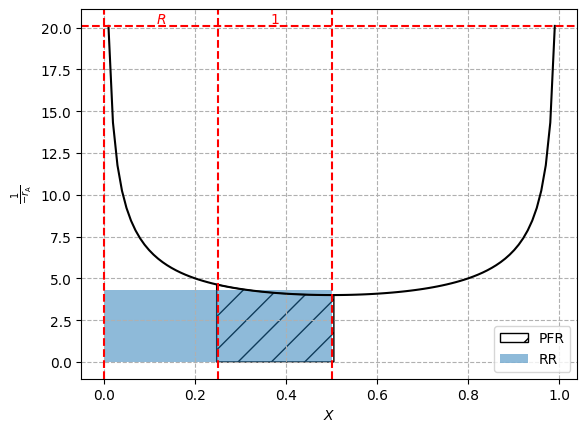

    n    Volumen    Tipo
-----------------------
   1   |  10.7826 | RR


In [42]:
### Indicar tipos de reactores, conversiones, y datos a tratar (x, y) ##########
R = 1
x1 = target

### Graficar datos #############################################################
fig, ax = plt.subplots()
ax.plot(x, y, color='k')
# encontrar indices cercanos a conversión inicial
x0 = R/(R+1) * x1
diffs0 = np.abs(x0 - x)
ind0 = diffs0.argmin()
# encontrar indices cercanos a conversión final
diffs1 = np.abs(x1 - x)
ind1 = diffs1.argmin()
# calcular y graficar el área que corresponde a cada reactor
area = (R+1) * trapezoid(y[ind0:ind1+1], x[ind0:ind1+1])
ax.fill_between(x[ind0:ind1+1], y[ind0:ind1+1], hatch='/', facecolor='None', edgecolor='k', label='PFR')
# calcular la altura promedio
height = area / x1
ax.fill_between([0, x1], [height, height], alpha=0.5, label='RR')
# Indicativo de R + 1...
ax.axvline(0, c='r', ls='--')
ax.annotate(f"$R$", xy=(x0/2, np.max(y)), va='bottom', ha='center', color='r')
ax.axvline(x0, c='r', ls='--')
ax.annotate(f"$1$", xy=((x0+x1)/2, np.max(y)), va='bottom', ha='center', color='r')
ax.axvline(x1, c='r', ls='--')
ax.axhline(np.max(y), c='r', ls='--')
# formato gráfico
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$\frac{1}{-r_{\mathrm{A}}}$")
ax.legend()
ax.grid(ls='--')
plt.show()

### Tratamiento de datos #######################################################
# Establecer flujo molar (regimen estacionario), calcular volumenes de reactores
Vols = F0 * area
# imprimir resultados brutos
print("    n    Volumen    Tipo")
print("-----------------------")
print(f"   1   | {Vols:8.4f} | {'RR'}")

## 5.3 Arreglos de reactores

**¿Qué combinación de reactores sería la óptima para una reacción autocatalítica?**

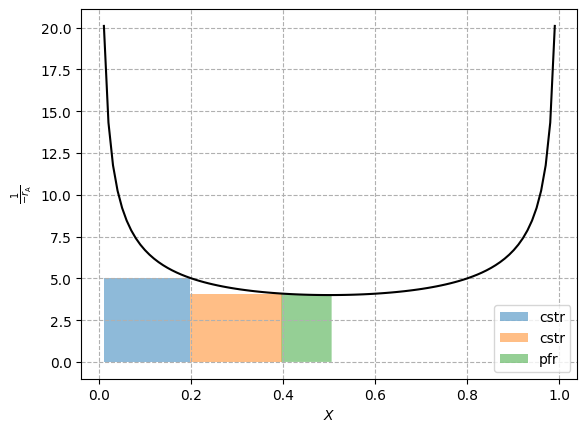

    n    Volumen    Tipo
-----------------------
    1 |   4.7191 | cstr
    2 |   4.0480 | cstr
    3 |   2.1931 | pfr
Volumen total: 10.9602


In [43]:
### Indicar tipos de reactores, conversiones, y datos a tratar (x, y) ##########
reactors = ['cstr', 'cstr', 'pfr']
targets = np.array([0.2, 0.4, 0.5])

### Graficar datos #############################################################
fig, ax = plt.subplots()
areas = np.zeros_like(targets)
ax.plot(x, y, color='k')
for ii, reactor in enumerate(reactors):
    # encontrar indices cercanos a conversión inicial
    if ii==0:
        x0 = 0.0
        ind0 = 0
    else:
        x0 = targets[ii-1]
        diffs0 = np.abs(x0 - x)
        ind0 = diffs0.argmin()
    # encontrar indices cercanos a conversión final
    x1 = targets[ii]
    diffs1 = np.abs(x1 - x)
    ind1 = diffs1.argmin()
    # calcular y graficar el área que corresponde a cada reactor
    if reactor.lower() == 'cstr':
        areas[ii] = (x[ind1] - x[ind0]) * y[ind1]
        ax.fill_between(x[ind0:ind1+1], y[ind1]*np.ones_like(x[ind0:ind1+1]), label=f'{reactor}', alpha=0.5)
    else:
        areas[ii] = trapezoid(y[ind0:ind1+1], x[ind0:ind1+1])
        ax.fill_between(x[ind0:ind1+1], y[ind0:ind1+1], label=f'{reactor}', alpha=0.5)
# formato gráfico
ax.set_xlabel(r"$X$")
ax.set_ylabel(r"$\frac{1}{-r_{\mathrm{A}}}$")
ax.legend()
ax.grid(ls='--')
plt.show()

### Tratamiento de datos #######################################################
# Establecer flujo molar (regimen estacionario), calcular volumenes de reactores
F0 = 5.0
Vols = F0 * areas
# imprimir resultados brutos
print("    n    Volumen    Tipo")
print("-----------------------")
for ii, reactor in enumerate(reactors):
    print(f"{ii+1:5} | {Vols[ii]:8.4f} | {reactor}")
print(f"Volumen total: {np.sum(Vols):.4f}")

# Referencias

- ***[Fogler, 2016]***: Fogler, H. S. (2016) Elements of Chemical Reaction Engineering (5th ed.). Prentice Education Inc.

- ***[Levenspiel, 1998]***: Levenspiel, O. (1998) Chemical Reaction Engineering (3rd ed.). John Wiley & Sons Inc. URL: https://www.wiley.com/en-no/Chemical+Reaction+Engineering%2C+3rd+Edition-p-9780471254249